# 05 — Attention с нуля: эксперименты

Правило: перед каждой ячейкой с кодом — «Предсказание». Прогноз пишу **до** запуска, после запуска — одна строка «Что увидел».

**Предсказание:** импорты и сид — ожидаю, что всё импортируется без ошибок.

_Мой прогноз:_ всё импортируется

**Что увидел:** импорт прошёл без ошибок

In [1]:
import math
import torch
import matplotlib.pyplot as plt
from attention import scaled_dot_product_attention, causal_mask, MultiHeadAttention
torch.manual_seed(0)

## Эксперимент 1: дисперсия скалярного произведения

**Предсказание:** q и k — векторы из N(0, 1) размерности d_k. 

_Мой прогноз:_ 
Чему примерно равна дисперсия q·k?
- Она равна ${d_k}^2$

А дисперсия $\frac{q·k}{\sqrt{d_k}}$?
- Она равна $d_k$

**Что увидел:** 

Чему примерно равна дисперсия q·k?
- d_k

А дисперсия $\frac{q·k}{\sqrt{d_k}}$?
- 1

In [ ]:
for d_k in [4, 16, 64, 256, 1024]:
    q = torch.randn(10_000, d_k)
    k = torch.randn(10_000, d_k)

    dot = (q * k).sum(dim=-1)  # попарные скалярные произведения, (10_000,)
    dot_scaled = dot / math.sqrt(d_k)

    print(f"d_k: {d_k:5d},  var(dot): {dot.var():8.3f},  var(dot / sqrt(d_k)): {dot_scaled.var():.3f}")

d_k:     4,  var(dot):    3.970,  var(dot / sqrt(d_k)): 0.992
d_k:    16,  var(dot):   15.933,  var(dot / sqrt(d_k)): 0.996
d_k:    64,  var(dot):   63.447,  var(dot / sqrt(d_k)): 0.991
d_k:   256,  var(dot):  258.702,  var(dot / sqrt(d_k)): 1.011
d_k:  1024,  var(dot): 1022.918,  var(dot / sqrt(d_k)): 0.999


## Эксперимент 2: что делает скейлинг с softmax и градиентом

**Предсказание:** d_k = 512, один запрос и 10 ключей. Какой будет максимальный вес softmax без скейлинга и со скейлингом? У какого варианта градиент по q будет больше?

_Мой прогноз:_ 

Без: близко к 1

С: Если мы применяем softmax к выборке с дисперсией = 1 и средним = 0, то я не знаю... трудно сказать, интуиция подсказывает, что не больше 0.5


Градиент будет больше без scaling


**Что увидел:** 

С градиентом ошибся – будет наоборот из-за насыщения softmax (производная по softmax пропорциональна w * (1 - w), а softmax(scores) при таком высоком разбросе и дают веса примерно 0 и 1) и градиент просто не проходит



In [13]:
torch.manual_seed(0)
d_k = 512
q = torch.randn(1, d_k, requires_grad=True)
K = torch.randn(10, d_k)
target = torch.randn(10)

for scale in [False, True]:
    scores = q @ K.T
    if scale:
        scores = scores / math.sqrt(d_k)
    w = torch.softmax(scores, dim=-1)
    loss = (w * target).sum()
    (grad,) = torch.autograd.grad(loss, q)
    print(f"scale={scale}:  max weight = {w.max().item():.4f},  "
          f"std scores = {scores.std().item():.2f},  |grad q| = {grad.norm().item()}")

scale=False:  max weight = 1.0000,  std scores = 19.86,  |grad q| = 1.2105833002706845e-09
scale=True:  max weight = 0.3401,  std scores = 0.88,  |grad q| = 0.4336858093738556


## Эксперимент 3: как выглядят causal-веса у необученной модели

**Предсказание:** модель не обучена, маска causal. Как примерно распределены веса в строке i?

_Мой прогноз:_

1. Будет лесенка: снизу от диагонали значения, сверху ~0
2. В строке 0 вес будет 1
3. Внимание распределится поровну, каждая позиция получит ~1/(i+1), в строке 7 — ~1/8

**Что увидел:**

1. Лесенка есть, причём сверху от диагонали ровно 0 (маска даёт `-inf`, а `exp(-inf) = 0`)
2. В строке 0 вес ровно 1
3. Почти поровну, но не идеально: в строке 7 веса от 0.06 до 0.20 вокруг 1/8 ≈ 0.125, в коротких строках разброс больше (строка 2: 0.65 / 0.15 / 0.19). Причина не в скейлинге, а в том, что у необученной модели веса `nn.Linear` маленькие, поэтому scores близки к 0 и softmax почти равномерный. Скейлинг лишь не даёт scores расти с `d_k` (в эксп. 2 со скейлингом max weight был 0.34, а не 0.1)

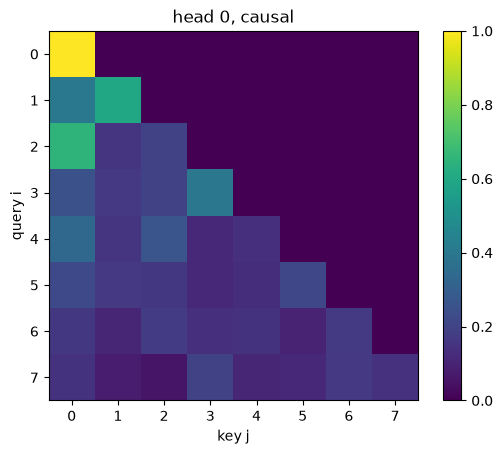

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4000, 0.6000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.6500, 0.1500, 0.1900, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.1600, 0.1900, 0.4000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3400, 0.1500, 0.2600, 0.1200, 0.1400, 0.0000, 0.0000, 0.0000],
        [0.2200, 0.1600, 0.1600, 0.1100, 0.1300, 0.2100, 0.0000, 0.0000],
        [0.1600, 0.1100, 0.1800, 0.1400, 0.1500, 0.1000, 0.1700, 0.0000],
        [0.1400, 0.0700, 0.0600, 0.2000, 0.1100, 0.1100, 0.1700, 0.1400]])


In [14]:
torch.manual_seed(0)
mha = MultiHeadAttention(d_model=32, n_heads=4)
x = torch.randn(1, 8, 32)
_, w = mha(x, causal_mask(8))
plt.imshow(w[0, 0].detach(), cmap="viridis")
plt.colorbar(); plt.xlabel("key j"); plt.ylabel("query i"); plt.title("head 0, causal")
plt.show()
print(w[0, 0].detach().round(decimals=2))